# Bernoulli experiment & Probability Estimation

- A student is trying to solve N=20 problems and the result is a sequence of 0's and 1's.
- The ability parameter of the student is $\theta$, which is also the probability of answering a question correctly.
- Y ~ Bernoulli(\theta)
- Question: What is the posterior probability of $\theta$ when a set of observations is provided.
- Stan/cmdstanpy & plots

## Table of Contents

1. 데이터와 문제 설정
2. Bayesian 모델 (Stan/cmdstanpy)
3. Posterior 요약과 시각화
4. Conjugate Beta posterior와 비교
5. 결론
6. Prior sensitivity: Beta(3,3), Beta(2,10) 비교
7. Beta(a, b) 모양 다양성

## 1. 데이터와 문제 설정

이 실습에서는 N=20개의 문항 정오답(0/1) 데이터를 이용해 학생 능력 파라미터 theta를 추정한다.
각 관측값은 Yi ~ Bernoulli(theta)로 가정한다.
목표는 관측 데이터가 주어졌을 때 theta의 posterior 분포를 구하고 해석하는 것이다.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from cmdstanpy import CmdStanModel

SEED = 42
rng = np.random.default_rng(SEED)

N = 20
# 예시 데이터: 필요하면 실제 관측값으로 교체
y = np.array([1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1], dtype=int)

k = int(y.sum())
print(f"N={N}, success={k}, failure={N-k}, sample proportion={k/N:.3f}")

N=20, success=14, failure=6, sample proportion=0.700


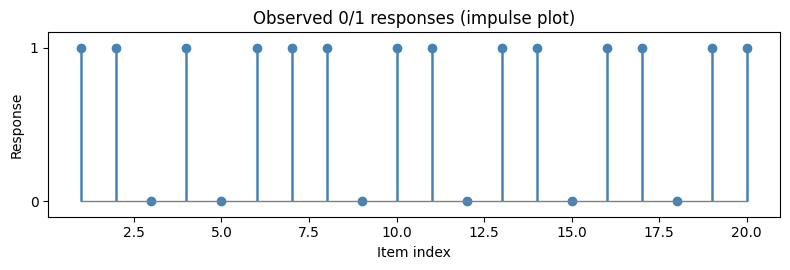

In [2]:
x = np.arange(1, N + 1)

plt.figure(figsize=(8, 2.8))
markerline, stemlines, baseline = plt.stem(x, y, linefmt="steelblue", markerfmt="o", basefmt="k-")
plt.setp(markerline, markerfacecolor="steelblue", markeredgecolor="steelblue")
plt.setp(stemlines, linewidth=1.8, color="steelblue")
plt.setp(baseline, linewidth=1.0, color="gray")

plt.yticks([0, 1])
plt.ylim(-0.1, 1.1)
plt.xlabel("Item index")
plt.ylabel("Response")
plt.title("Observed 0/1 responses (impulse plot)")
plt.tight_layout()
plt.show()

## 2. Bayesian 모델

모형:
- Yi ~ Bernoulli(theta)
- theta ~ Beta(1, 1) (uniform prior)

이 설정에서 posterior는 성공 수와 실패 수를 prior에 더해 업데이트된다.

In [3]:
stan_code = """
data {
  int<lower=1> N;
  array[N] int<lower=0,upper=1> y;
}
parameters {
  real<lower=0,upper=1> theta;
}
model {
  theta ~ beta(1, 1);
  y ~ bernoulli(theta);
}
"""

with open("bernoulli_probability_estimation.stan", "w", encoding="utf-8") as f:
    f.write(stan_code)

model = CmdStanModel(stan_file="bernoulli_probability_estimation.stan")
fit = model.sample(
    data={"N": int(N), "y": y.tolist()},
    chains=4,
    parallel_chains=4,
    iter_warmup=1000,
    iter_sampling=2000,
    seed=SEED,
    show_progress=False,
)

posterior = fit.draws_pd(vars=["theta"])
theta_samples = posterior["theta"].to_numpy()

summary = fit.summary()
theta_row = summary.loc["theta"] if "theta" in summary.index else summary.iloc[0]

# CmdStanPy version마다 summary 컬럼명이 다를 수 있어, 존재하는 컬럼만 선택해서 출력
candidate_cols = ["Mean", "mean", "SD", "sd", "2.5%", "5%", "50%", "95%", "97.5%"]
available_cols = [c for c in candidate_cols if c in summary.columns]

if available_cols:
    print(theta_row[available_cols])
else:
    print(theta_row)

23:56:55 - cmdstanpy - INFO - compiling stan file D:\KOS-5101\intro-bayes\bernoulli_probability_estimation.stan to exe file D:\KOS-5101\intro-bayes\bernoulli_probability_estimation.exe
23:57:07 - cmdstanpy - INFO - compiled model executable: D:\KOS-5101\intro-bayes\bernoulli_probability_estimation.exe
23:57:08 - cmdstanpy - INFO - CmdStan start processing
23:57:08 - cmdstanpy - INFO - Chain [1] start processing
23:57:08 - cmdstanpy - INFO - Chain [2] start processing
23:57:08 - cmdstanpy - INFO - Chain [3] start processing
23:57:08 - cmdstanpy - INFO - Chain [4] start processing
23:57:08 - cmdstanpy - INFO - Chain [1] done processing
23:57:08 - cmdstanpy - INFO - Chain [4] done processing
23:57:08 - cmdstanpy - INFO - Chain [3] done processing
23:57:08 - cmdstanpy - INFO - Chain [2] done processing


Mean    0.679113
5%      0.510442
50%     0.683883
95%     0.831148
Name: theta, dtype: float64


## 3. Posterior 요약과 시각화

posterior 평균, 중앙값, 95% credible interval을 계산하고 분포를 시각화한다.

Posterior mean(theta): 0.6791
Posterior median(theta): 0.6839
95% CrI: (0.4756, 0.8538)


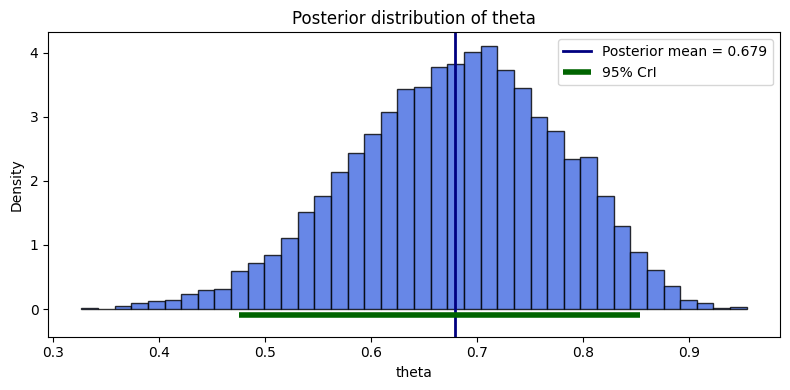

In [4]:
theta_mean = theta_samples.mean()
theta_median = np.median(theta_samples)
theta_low, theta_high = np.quantile(theta_samples, [0.025, 0.975])

print(f"Posterior mean(theta): {theta_mean:.4f}")
print(f"Posterior median(theta): {theta_median:.4f}")
print(f"95% CrI: ({theta_low:.4f}, {theta_high:.4f})")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(theta_samples, bins=40, color="royalblue", edgecolor="black", alpha=0.8, density=True)
ax.axvline(theta_mean, color="navy", linewidth=2, label=f"Posterior mean = {theta_mean:.3f}")
ax.hlines(y=-0.02 * ax.get_ylim()[1], xmin=theta_low, xmax=theta_high, color="darkgreen", linewidth=4, label="95% CrI")
ax.set_ylim(bottom=-0.1 * ax.get_ylim()[1], top=ax.get_ylim()[1])
ax.set_xlabel("theta")
ax.set_ylabel("Density")
ax.set_title("Posterior distribution of theta")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Conjugate Beta posterior와 비교

Bernoulli-Beta conjugacy에 의해 posterior는 Beta(1+k, 1+N-k)이다.
Stan 샘플 기반 추정과 닫힌형식(closed-form) 결과가 일관적인지 확인한다.

In [5]:
a_post = 1 + k
b_post = 1 + (N - k)

# Beta(a, b)의 평균은 a / (a + b)
theta_mean_closed_form = a_post / (a_post + b_post)
print(f"Closed-form posterior mean: {theta_mean_closed_form:.4f}")
print(f"Stan posterior mean      : {theta_mean:.4f}")

Closed-form posterior mean: 0.6818
Stan posterior mean      : 0.6791


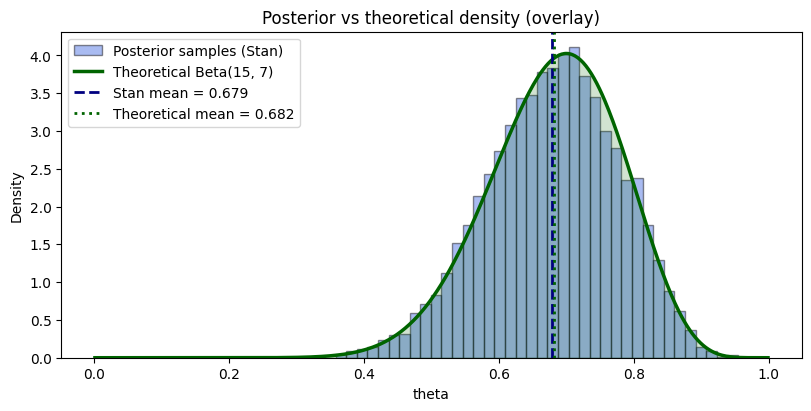

In [6]:
from scipy.stats import beta

# Grid for the analytic Beta posterior
x_grid = np.linspace(0.001, 0.999, 500)
beta_pdf = beta.pdf(x_grid, a_post, b_post)

# Overlay: posterior histogram density + closed-form Beta posterior
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)

ax.hist(
    theta_samples,
    bins=40,
    density=True,
    color="royalblue",
    alpha=0.45,
    edgecolor="black",
    label="Posterior samples (Stan)",
)
ax.plot(x_grid, beta_pdf, color="darkgreen", linewidth=2.5, label=f"Theoretical Beta({a_post}, {b_post})")
ax.fill_between(x_grid, beta_pdf, color="darkgreen", alpha=0.18)
ax.axvline(theta_mean, color="navy", linewidth=2, linestyle="--", label=f"Stan mean = {theta_mean:.3f}")
ax.axvline(theta_mean_closed_form, color="darkgreen", linewidth=2, linestyle=":", label=f"Theoretical mean = {theta_mean_closed_form:.3f}")

ax.set_title("Posterior vs theoretical density (overlay)")
ax.set_xlabel("theta")
ax.set_ylabel("Density")
ax.legend()

plt.show()

Posterior predictive for the next 10 problems:
The number of future problems: 10
The number of posterior predictive samples: 8000
Posterior predictive samples (first 10): [4 5 4 5 8 2 4 4 7 6]
Posterior predictive mean correct (out of 10): 6.810
Posterior predictive median correct: 7
95% predictive interval: [3, 10]
P(X >= 8) = 0.375


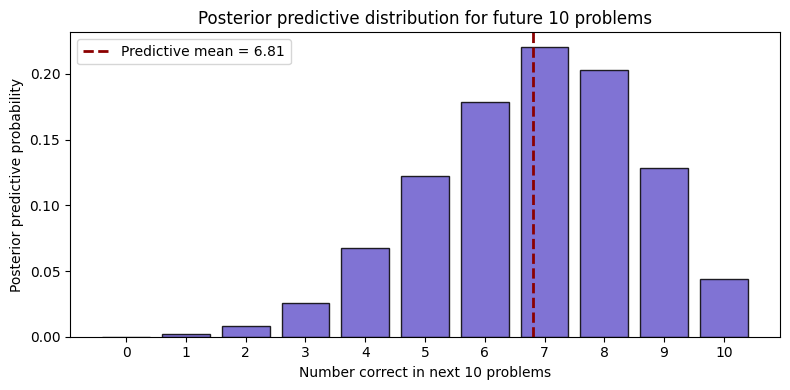

In [7]:
# Posterior predictive for the next 10 problems
n_future = 10

# For each posterior sample theta^(s), simulate future correct count ~ Binomial(10, theta^(s))
pred_correct = rng.binomial(n=n_future, p=theta_samples)

pred_mean = pred_correct.mean()
pred_median = np.median(pred_correct)
pred_low, pred_high = np.quantile(pred_correct, [0.025, 0.975])

print("Posterior predictive for the next 10 problems:")
print(f"The number of future problems: {n_future}")
print(f"The number of posterior predictive samples: {len(pred_correct)}")
print(f"Posterior predictive samples (first 10): {pred_correct[:10]}")
print(f"Posterior predictive mean correct (out of {n_future}): {pred_mean:.3f}")
print(f"Posterior predictive median correct: {pred_median:.0f}")
print(f"95% predictive interval: [{pred_low:.0f}, {pred_high:.0f}]")
print(f"P(X >= 8) = {(pred_correct >= 8).mean():.3f}")

# Discrete predictive distribution plot
values = np.arange(0, n_future + 1)
probs = np.array([(pred_correct == v).mean() for v in values])

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(values, probs, width=0.8, color="slateblue", alpha=0.85, edgecolor="black")
ax.axvline(pred_mean, color="darkred", linestyle="--", linewidth=2, label=f"Predictive mean = {pred_mean:.2f}")
ax.set_xticks(values)
ax.set_xlabel("Number correct in next 10 problems")
ax.set_ylabel("Posterior predictive probability")
ax.set_title("Posterior predictive distribution for future 10 problems")
ax.legend()
plt.tight_layout()
plt.show()

## 5. 결론

데이터의 성공/실패 정보가 prior를 업데이트해 theta posterior를 만든다.
posterior 분포를 통해 점추정과 불확실성(credible interval)을 함께 보고할 수 있다.

## 6. Prior sensitivity: Beta(3,3), Beta(2,10) 비교

같은 관측 데이터(성공 수 `k`, 총 문항 수 `N`)에 대해 prior를 바꿨을 때 posterior가 어떻게 달라지는지 비교한다.

- 실험 A: prior = Beta(1,1)  (기준 실험, 균등 prior)
- 실험 B: prior = Beta(3,3)
- 실험 C: prior = Beta(2,10)

Bernoulli-Beta conjugacy에 의해 posterior는

- `posterior = Beta(a0 + k, b0 + N - k)`

형태가 된다.

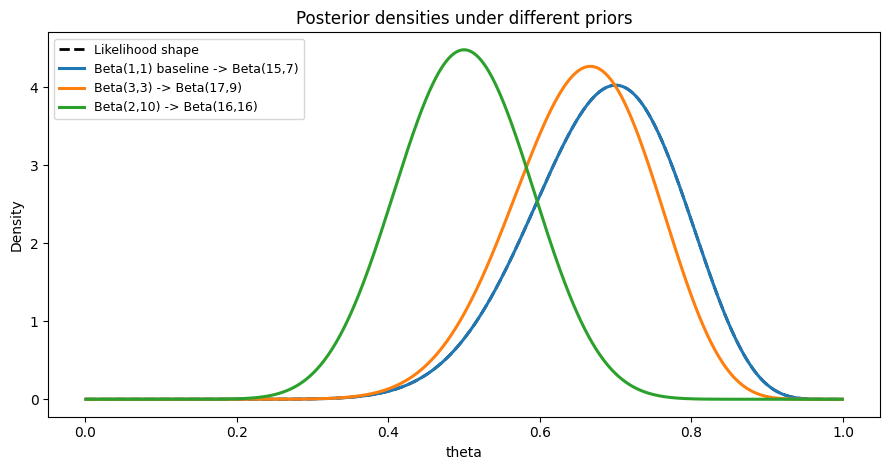

Observed data: k=14 successes out of N=20
----------------------------------------------------------------------
Prior: Beta(1,1) baseline
Posterior: Beta(15, 7)
Posterior mean(theta): 0.6818
Posterior 95% CrI: (0.4782, 0.8541)
Predictive mean correct (next 10): 6.824
Predictive 95% interval: [3, 10]
----------------------------------------------------------------------
Prior: Beta(3,3)
Posterior: Beta(17, 9)
Posterior mean(theta): 0.6538
Posterior 95% CrI: (0.4650, 0.8203)
Predictive mean correct (next 10): 6.537
Predictive 95% interval: [3, 10]
----------------------------------------------------------------------
Prior: Beta(2,10)
Posterior: Beta(16, 16)
Posterior mean(theta): 0.5000
Posterior 95% CrI: (0.3306, 0.6694)
Predictive mean correct (next 10): 5.010
Predictive 95% interval: [2, 8]


In [8]:
from scipy.stats import beta

prior_settings = [
    (1, 1, "Beta(1,1) baseline"),
    (3, 3, "Beta(3,3)"),
    (2, 10, "Beta(2,10)"),
]

x_grid = np.linspace(0.001, 0.999, 600)

results = []
fig, ax = plt.subplots(figsize=(9, 4.8))

# Observed-data likelihood shape (up to proportionality): theta^k (1-theta)^(N-k)
like_shape = (x_grid ** k) * ((1 - x_grid) ** (N - k))
like_shape = like_shape / np.trapezoid(like_shape, x_grid)
ax.plot(x_grid, like_shape, color="black", linewidth=2, linestyle="--", label="Likelihood shape")

for a0, b0, name in prior_settings:
    a_post_i = a0 + k
    b_post_i = b0 + (N - k)

    # Posterior summary
    post_mean = a_post_i / (a_post_i + b_post_i)
    ci_low, ci_high = beta.ppf([0.025, 0.975], a_post_i, b_post_i)

    # Posterior predictive for next 10 problems
    pred_samples = rng.binomial(n=10, p=rng.beta(a_post_i, b_post_i, size=60000))
    pred_mean = pred_samples.mean()
    pred_low, pred_high = np.quantile(pred_samples, [0.025, 0.975])

    results.append({
        "prior": name,
        "posterior": f"Beta({a_post_i}, {b_post_i})",
        "post_mean": post_mean,
        "post_95ci": (ci_low, ci_high),
        "pred_mean_out_of_10": pred_mean,
        "pred_95pi": (pred_low, pred_high),
    })

    post_pdf = beta.pdf(x_grid, a_post_i, b_post_i)
    ax.plot(x_grid, post_pdf, linewidth=2.2, label=f"{name} -> Beta({a_post_i},{b_post_i})")

ax.set_title("Posterior densities under different priors")
ax.set_xlabel("theta")
ax.set_ylabel("Density")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"Observed data: k={k} successes out of N={N}")
for r in results:
    print("-" * 70)
    print(f"Prior: {r['prior']}")
    print(f"Posterior: {r['posterior']}")
    print(f"Posterior mean(theta): {r['post_mean']:.4f}")
    print(f"Posterior 95% CrI: ({r['post_95ci'][0]:.4f}, {r['post_95ci'][1]:.4f})")
    print(f"Predictive mean correct (next 10): {r['pred_mean_out_of_10']:.3f}")
    print(f"Predictive 95% interval: [{r['pred_95pi'][0]:.0f}, {r['pred_95pi'][1]:.0f}]")

### 해석

1. **Beta(3,3)의 의미**
- prior mean은 `3/(3+3)=0.5`로, 정답확률이 0.5 근처라는 사전 믿음을 반영한다.
- Beta(1,1)보다 중심(0.5) 쪽으로 더 집중되어 있어(유사 표본 크기 약 6), 데이터가 같아도 posterior가 약간 0.5 방향으로 수축한다.
- 현재 데이터에서는 성공률이 높기 때문에 posterior 중심은 여전히 높은 구간에 있지만, Beta(1,1) 대비 소폭 보수적으로 이동한다.

2. **Beta(2,10)의 의미**
- prior mean은 `2/(2+10)=0.1667`로, 학생 정답확률이 낮다는 강한 사전 믿음을 뜻한다.
- 유사 표본 크기 약 12의 prior 정보가 들어가므로, 같은 데이터를 보더라도 posterior가 다른 두 실험보다 더 낮은 theta 쪽으로 당겨진다.
- 따라서 다음 10문항 예측에서도 평균 정답 수가 더 낮아지고, 분포도 상대적으로 왼쪽으로 이동한다.

3. **세 실험 비교 해석**
- 데이터가 충분히 강하면(표본 수가 크면) prior 차이 영향은 줄어든다.
- 표본 수가 작거나 prior가 강할수록(Beta(2,10)처럼) posterior와 예측 결과 차이가 커진다.
- 즉, posterior는 `likelihood(데이터)`와 `prior(사전 믿음)`의 절충 결과다.

## 7. Beta(a, b) 모양 다양성

아래 플롯은 Beta 분포의 두 파라미터 `a`, `b`가 바뀔 때 분포 모양이 어떻게 달라지는지 보여준다.

- `a=b=1`: 균등분포
- `a,b > 1`: 가운데 봉우리(종 모양)
- `a < 1` 또는 `b < 1`: 경계(0 또는 1) 근처에서 뾰족
- `a > b`: 1 쪽으로 치우침
- `a < b`: 0 쪽으로 치우침

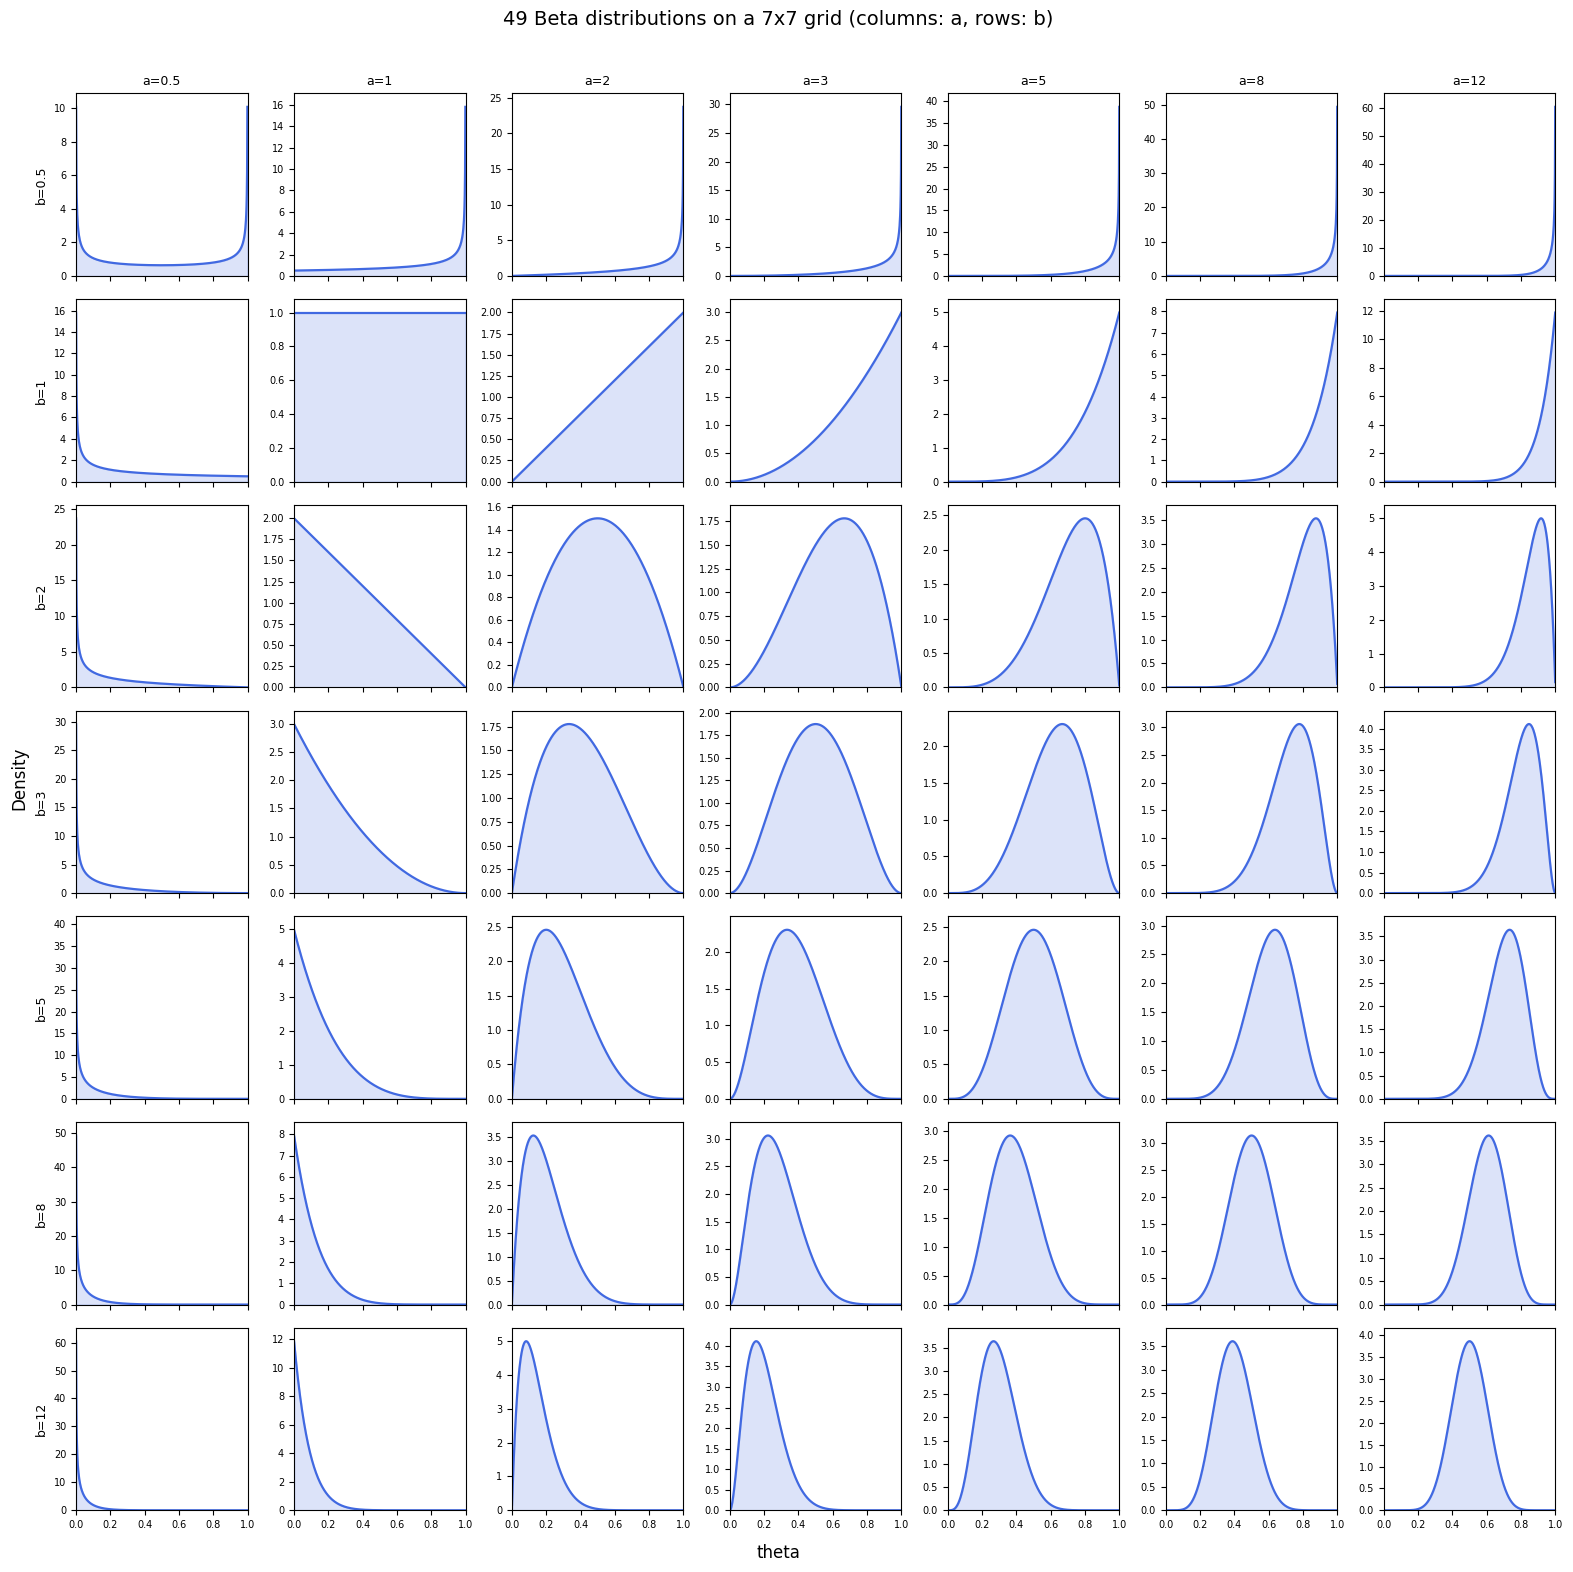

In [9]:
# 7x7 grid of Beta distributions
# x-axis of the grid indexes parameter a, y-axis indexes parameter b
# Each panel uses its own y-scale (heights are not forced to be the same).

a_values = [0.5, 1, 2, 3, 5, 8, 12]
b_values = [0.5, 1, 2, 3, 5, 8, 12]

x = np.linspace(0.001, 0.999, 600)
fig, axes = plt.subplots(7, 7, figsize=(16, 16), sharex=True)

for row, b in enumerate(b_values):
    for col, a in enumerate(a_values):
        ax = axes[row, col]
        y_pdf = beta.pdf(x, a, b)
        ax.plot(x, y_pdf, color="royalblue", linewidth=1.6)
        ax.fill_between(x, y_pdf, color="royalblue", alpha=0.18)
        ax.set_xlim(0, 1)

        # Give each panel its own y-scale
        ymax = float(np.max(y_pdf))
        ax.set_ylim(0, ymax * 1.08)

        # Top row: show a values (grid x-axis meaning)
        if row == 0:
            ax.set_title(f"a={a}", fontsize=9)

        # Left column: show b values (grid y-axis meaning)
        if col == 0:
            ax.set_ylabel(f"b={b}", fontsize=9)

        ax.tick_params(labelsize=7)

fig.suptitle("49 Beta distributions on a 7x7 grid (columns: a, rows: b)", fontsize=14)
fig.supxlabel("theta", fontsize=12)
fig.supylabel("Density", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()